<img src="../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../images/Konstanz_Logo.svg" width="200" /> <img src="../images/KIT_Logo.png" width="200" />

# Visualization with Matplotlib

**Matplotlib** is the most widely used plotting library in Python, and the oldest of
the three in this chapter. Almost every other plotting package either builds on it
or borrows its vocabulary.

It is the opposite of hvPlot in temperament. hvPlot decides things for you;
matplotlib decides almost nothing. Nearly every property of a figure is yours to
set — which is exactly why the default output looks plain, and why a finished
matplotlib figure can look like anything you want.

---

## Contents

1. [The data](#data)
2. [Basic plotting](#basic)
3. [Scatter plots](#scatter)
4. [A second dataset: two populations](#populations)
5. [The object-oriented interface](#oo)
6. [Histograms and contour plots](#hist)
7. [Saving a figure](#saving)

<a id="data"></a>
## 1. The data

We start with the same eight university cities used in the hvPlot notebook.

| Column | Meaning |
|---|---|
| **Name** | Name of the city |
| **Population** | Number of inhabitants |
| **Area** | Area of the city in km² |
| **Students** | Number of enrolled students |
| **Percentage** | Students as a percentage of the population |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tell matplotlib to draw inside the notebook
%matplotlib inline

df = pd.read_csv("University_Cities.csv")
df

,Name,Population,Area,Students,Percentage
0,Freiburg,230241,153.04,32677,14.19
1,Heidelberg,160355,108.83,36274,22.62
2,Karlsruhe,313092,173.42,37565,12.00
3,Konstanz,84911,54.12,16740,19.71
4,Mannheim,309370,144.97,28183,9.11
5,Stuttgart,634830,207.32,53870,8.49
6,Tübingen,92811,108.06,28010,30.18
7,Ulm,126329,118.68,13296,10.52


<a id="basic"></a>
## 2. Basic plotting

`plt.plot()` draws a line. Give it something for the x-axis, something for the
y-axis, and call `plt.show()`.

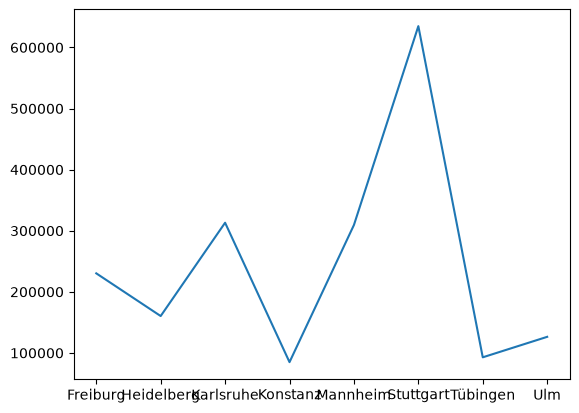

In [2]:
plt.plot(df["Name"], df["Population"])

plt.show()

It works, but it is barely readable: no title, no axis labels, and the city names
are crammed together along the bottom.

This is matplotlib's character in one picture. It drew exactly what it was asked
for and nothing more. Everything else has to be added — which takes a few lines,
but each one is obvious.

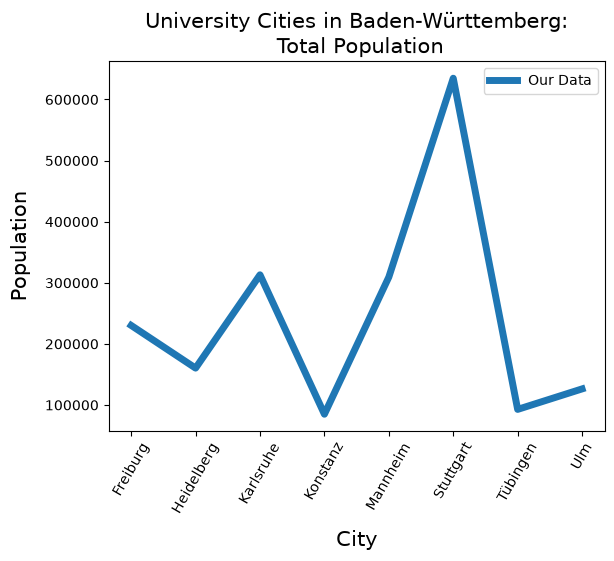

In [3]:
plt.plot(df["Name"], df["Population"], linewidth=5, label="Our Data")

# a title, with a line break in it
plt.title("University Cities in Baden-Württemberg:\n Total Population", fontsize=15)

# axis labels; labelpad pushes them away from the axis
plt.xlabel("City", labelpad=10, fontsize=15)
plt.ylabel("Population", labelpad=10, fontsize=15)

# a legend -- with no arguments, matplotlib places it automatically
plt.legend()

# rotate the city names so they stop overlapping
plt.xticks(rotation=60)

plt.show()

Much better.

Changing the *type* of plot is a matter of changing one function. Everything
around it stays as it was.

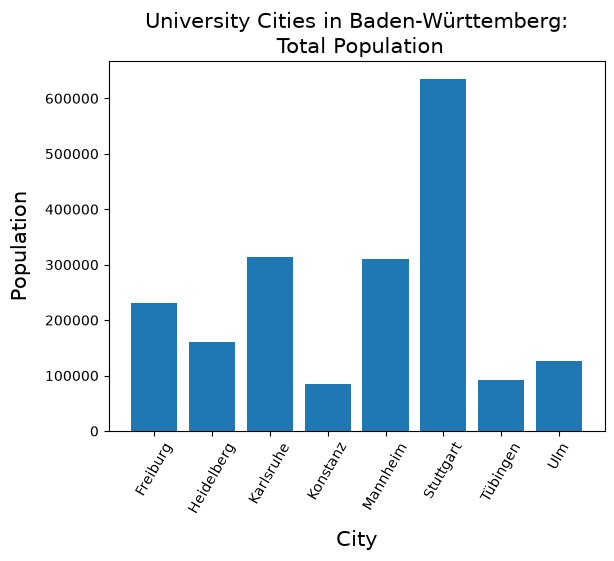

In [4]:
plt.bar(df["Name"], df["Population"], lw=5)

plt.title("University Cities in Baden-Württemberg:\n Total Population", fontsize=15)

plt.xlabel("City", labelpad=10, fontsize=15)
plt.ylabel("Population", labelpad=10, fontsize=15)

plt.xticks(rotation=60)

plt.show()

<a id="scatter"></a>
## 3. Scatter plots

`plt.scatter()` draws individual points instead of connecting them.

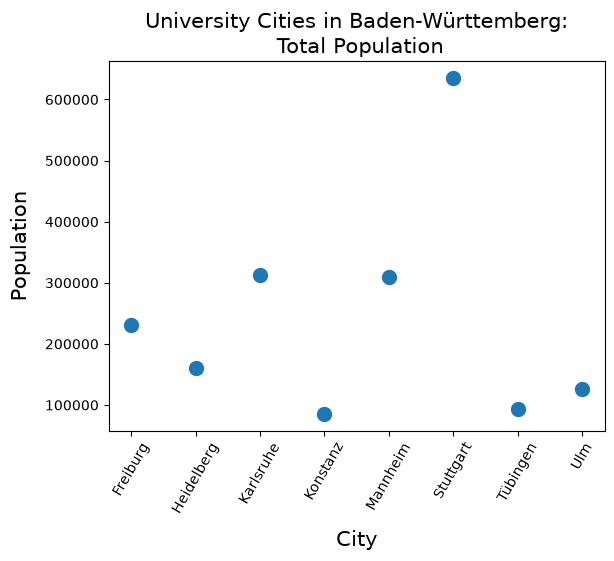

In [5]:
plt.scatter(df["Name"], df["Population"], lw=5)

plt.title("University Cities in Baden-Württemberg:\n Total Population", fontsize=15)

plt.xlabel("City", labelpad=10, fontsize=15)
plt.ylabel("Population", labelpad=10, fontsize=15)

plt.xticks(rotation=60)

plt.show()

The markers themselves are adjustable: `marker` for the shape, `s` for the size,
`lw` for the line width and `c` for the colour.

- [marker styles](https://matplotlib.org/stable/api/markers_api.html)
- [named colours](https://matplotlib.org/stable/gallery/color/named_colors.html)

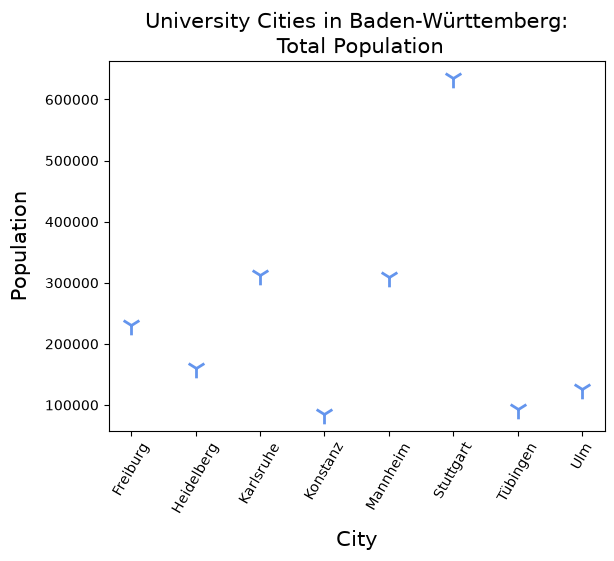

In [6]:
plt.scatter(df["Name"], df["Population"], marker='1', s=200, lw=2, c='cornflowerblue')

plt.title("University Cities in Baden-Württemberg:\n Total Population", fontsize=15)

plt.xlabel("City", labelpad=10, fontsize=15)
plt.ylabel("Population", labelpad=10, fontsize=15)

plt.xticks(rotation=60)

plt.show()

The full catalogue of what matplotlib can draw is worth a browse:
[matplotlib.org/stable/gallery](https://matplotlib.org/stable/gallery/#)

<a id="populations"></a>
## 4. A second dataset: two populations

Eight cities are not enough to show what scatter plots are actually good for. For
that we switch to a second file, `Two_Populations.csv` — **3000 artificial
measurements** in two dimensions, of the kind you might get out of an experiment.

| Column | Meaning |
|---|---|
| **x** | Position along the first dimension |
| **y** | Position along the second dimension |
| **group** | Which of the three sources the point came from |

The three sources are the point of it:

- **`background`** — 1000 points spread evenly over the whole area, simulating noise
- **`population_1`** — 1000 points clustered around (6, 5)
- **`population_2`** — 1000 points clustered around (2, 4)

In other words, two real signals buried in uniform background noise. The question
every plot below is really asking is: **can you see the two populations?**

In [7]:
points = pd.read_csv("Two_Populations.csv")

points.head()

,x,y,group
0,7.7396,0.6206,background
1,4.3888,4.5826,background
2,8.5860,1.2903,background
3,6.9737,1.5233,background
4,0.9418,6.3228,background


In [8]:
points["group"].value_counts()

group
background      1000
population_1    1000
population_2    1000
Name: count, dtype: int64

Drawing the three groups as three separate scatter plots gives each its own colour
automatically.

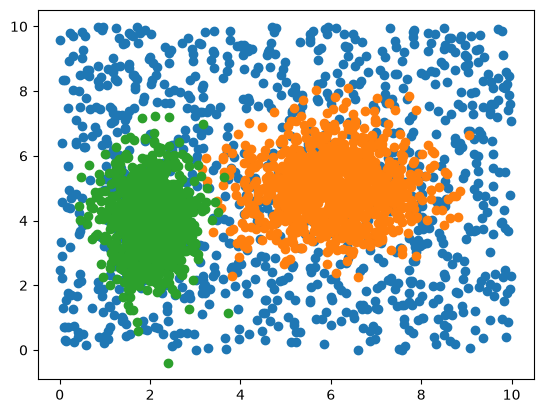

In [9]:
background = points[points["group"] == "background"]
pop_1 = points[points["group"] == "population_1"]
pop_2 = points[points["group"] == "population_2"]

plt.scatter(background["x"], background["y"], lw=1)
plt.scatter(pop_1["x"], pop_1["y"], lw=1)
plt.scatter(pop_2["x"], pop_2["y"], lw=1)

plt.show()

3000 opaque markers on top of each other hide as much as they show. The `alpha`
parameter makes them transparent, so that regions where many points overlap come
out darker — which is precisely the information we want.

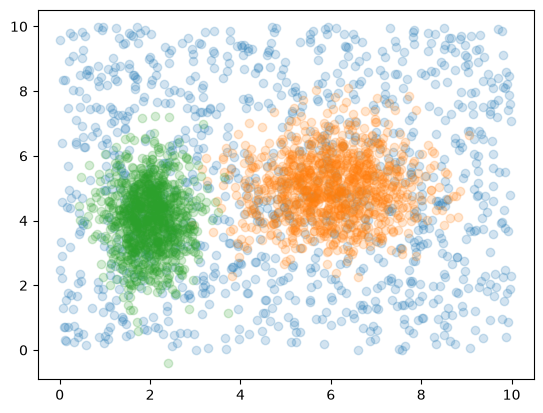

In [10]:
plt.scatter(background["x"], background["y"], lw=1, alpha=0.2)
plt.scatter(pop_1["x"], pop_1["y"], lw=1, alpha=0.2)
plt.scatter(pop_2["x"], pop_2["y"], lw=1, alpha=0.2)

plt.show()

In real data nobody hands you the `group` column — that is the answer, not the
input. So from here on we use all 3000 points together, as they would actually
arrive, and see how much of the structure can be recovered.

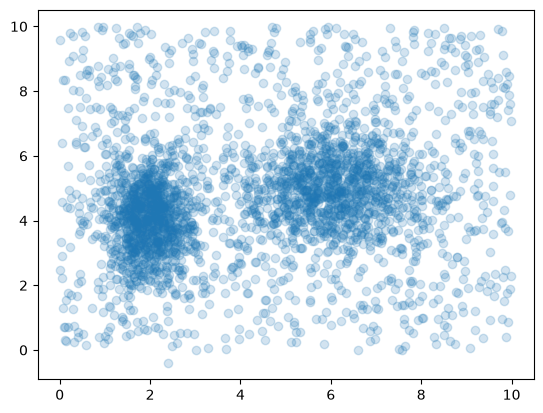

In [11]:
plt.scatter(points["x"], points["y"], alpha=0.2)

plt.show()

<a id="oo"></a>
## 5. The object-oriented interface

Everything so far went through `plt.something()`, which draws into whatever figure
happens to be current. That is convenient for one plot and awkward for several.

Matplotlib has a second interface in which the figure and its panels are **objects
you hold on to**. `plt.subplot()` hands back an `Axes` — one set of coordinates —
and you draw into it explicitly.

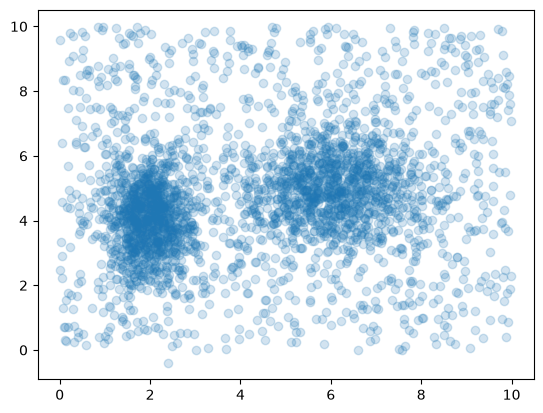

<class 'matplotlib.axes._axes.Axes'>


In [12]:
ax = plt.subplot()
ax.scatter(points["x"], points["y"], alpha=0.2)

plt.show()

print(type(ax))

The picture is identical; what changed is that we now have a handle on it. Titles
and labels are set *through* that object, with `set_` methods rather than bare
functions.

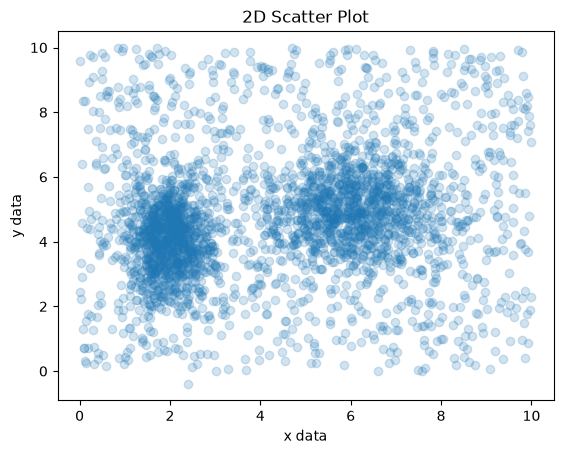

In [13]:
ax = plt.subplot()
ax.scatter(points["x"], points["y"], alpha=0.2)

ax.set_title("2D Scatter Plot")
ax.set_xlabel("x data")
ax.set_ylabel("y data")

plt.show()

<a id="hist"></a>
## 6. Histograms and contour plots

A scatter plot shows where points are. A **histogram** counts how many fall into
each interval, which answers a different question — and for 3000 overlapping points
it is often the clearer one.

Here is the `x` dimension alone, in 10 bins.

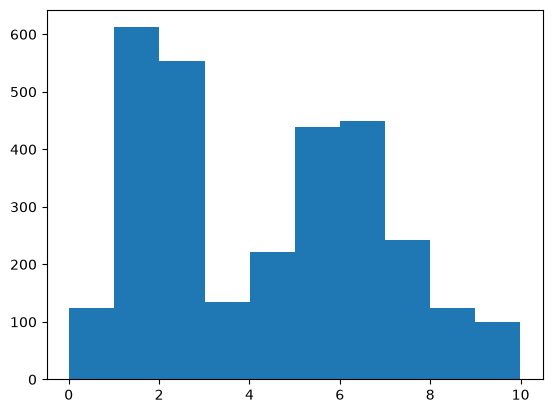

In [14]:
ax = plt.subplot()
histx = ax.hist(points["x"], bins=10)

The number of bins changes what you can see. With 100 bins the `y` dimension shows
far more detail — and the bump from the two populations sitting around y = 4 and
y = 5 becomes visible on top of the flat background.

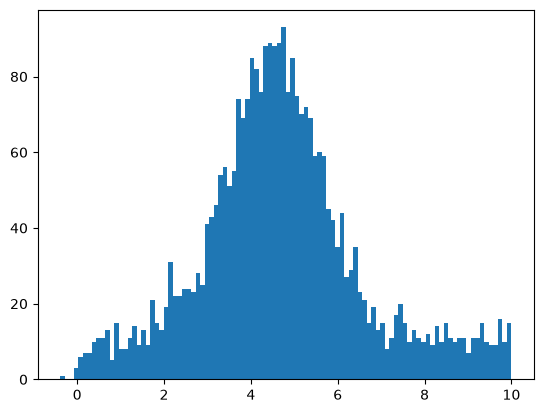

In [15]:
ax = plt.subplot()
histy = ax.hist(points["y"], bins=100)

This is where holding on to the objects pays off. With `gridspec` we can lay out
three panels — the scatter plot with its two histograms along the edges — and have
them **share axes**, so that the histogram above lines up exactly with the scatter
below it.

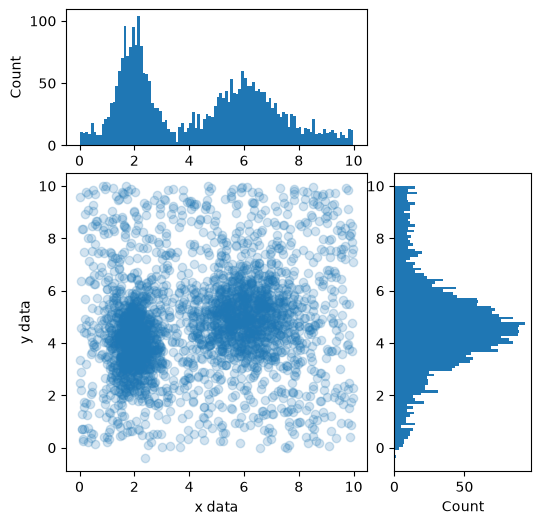

In [16]:
import matplotlib.gridspec as gridspec

fig_sc = plt.figure(figsize=(6, 6))

gs = gridspec.GridSpec(3, 3)
ax_scatter = plt.subplot(gs[1:3, :2])
ax_histx = plt.subplot(gs[0, :2], sharex=ax_scatter)
ax_histy = plt.subplot(gs[1:3, 2], sharey=ax_scatter)

ax_scatter.scatter(points["x"], points["y"], alpha=0.2, lw=1)
ax_scatter.set(xlabel="x data", ylabel="y data")

ax_histx.hist(points["x"], bins=100, align='mid')
ax_histx.set(ylabel='Count')

ax_histy.hist(points["y"], bins=100, orientation='horizontal', align='mid')
ax_histy.set(xlabel='Count')

plt.show()

Counting in **two** dimensions at once gives yet another view. The four panels below
are four ways of drawing the same 3000 points:

- **scatter** — every point individually
- **2D histogram** — a grid of boxes, coloured by how many points fell in each
- **hexbin** — the same idea with hexagonal boxes, which tile the plane more evenly
- **contour** — lines joining places of equal density, like heights on a map

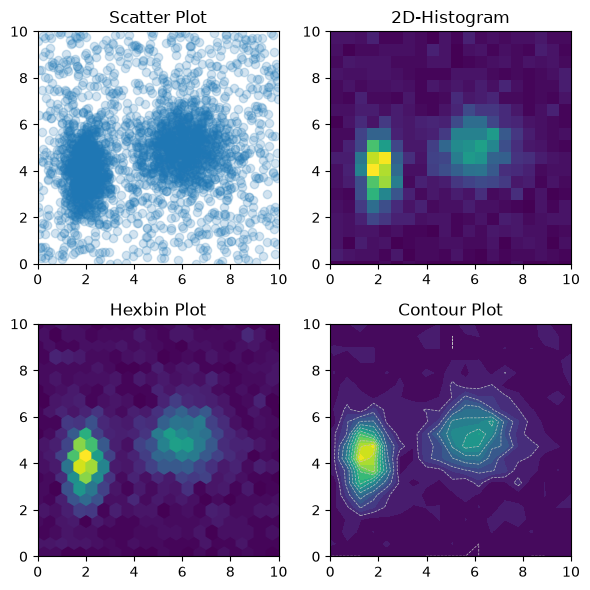

In [17]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))

axs[0, 0].set_title('Scatter Plot')
axs[0, 0].scatter(points["x"], points["y"], alpha=0.2, lw=1)

axs[0, 1].set_title('2D-Histogram')
axs[0, 1].hist2d(points["x"], points["y"], bins=20, cmap='viridis')

axs[1, 0].set_title('Hexbin Plot')
axs[1, 0].hexbin(points["x"], points["y"], gridsize=20, cmap='viridis')

axs[1, 1].set_title('Contour Plot')
# numpy does the counting, matplotlib only draws the result
hist, xedges, yedges = np.histogram2d(points["y"], points["x"], density=True, bins=20)
axs[1, 1].contour(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                  levels=10, colors='silver', linestyles='--', linewidths=0.5)
axs[1, 1].contourf(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                   levels=20, cmap='viridis')

# without this, matplotlib leaves whitespace around the data in each panel
for x in range(2):
    for y in range(2):
        axs[x, y].set_xlim([0, 10])
        axs[x, y].set_ylim([0, 10])

fig.tight_layout()
plt.show()

There is a problem in the top-right and bottom-left panels: an **empty** box and a
box holding one or two points are drawn in almost the same colour, so you cannot
tell "nothing here" from "almost nothing here".

The fix is `vmin` — a floor below which a box is not drawn at all. Set it just above
zero, and give the colormap a background colour to show through where nothing was
drawn.

In [18]:
# viridis, with white showing through wherever a bin falls below vmin
vir = plt.get_cmap("viridis")
vir.set_under('w')

# the same for plasma
plasm = plt.get_cmap("plasma")
plasm.set_under('w')

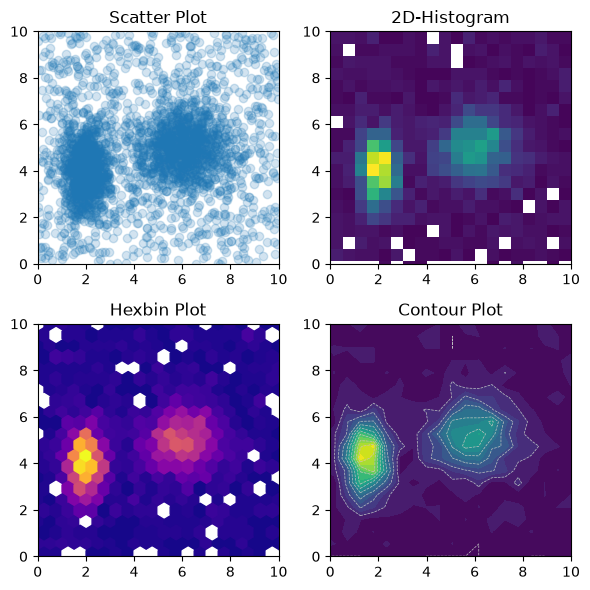

In [19]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))

axs[0, 0].set_title('Scatter Plot')
axs[0, 0].scatter(points["x"], points["y"], alpha=0.2, lw=1)

axs[0, 1].set_title('2D-Histogram')
axs[0, 1].hist2d(points["x"], points["y"], bins=20, cmap=vir, vmin=1e-14)

axs[1, 0].set_title('Hexbin Plot')
axs[1, 0].hexbin(points["x"], points["y"], gridsize=20, cmap=plasm, vmin=1e-14)

axs[1, 1].set_title('Contour Plot')
hist, xedges, yedges = np.histogram2d(points["y"], points["x"], density=True, bins=20)
axs[1, 1].contour(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                  levels=10, colors='silver', linestyles='--', linewidths=0.5)
axs[1, 1].contourf(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                   levels=20, cmap="viridis")

for x in range(2):
    for y in range(2):
        axs[x, y].set_xlim([0, 10])
        axs[x, y].set_ylim([0, 10])

fig.tight_layout()
plt.show()

Now the empty regions are genuinely blank, and both populations stand out clearly
against the background.

Small changes make a large difference to these panels. Below: star-shaped markers,
50 bins instead of 20 in the 2D histogram, and a reversed colormap (`viridis_r` —
the `_r` suffix reverses any matplotlib colormap) with one contour line per
histogram bin.

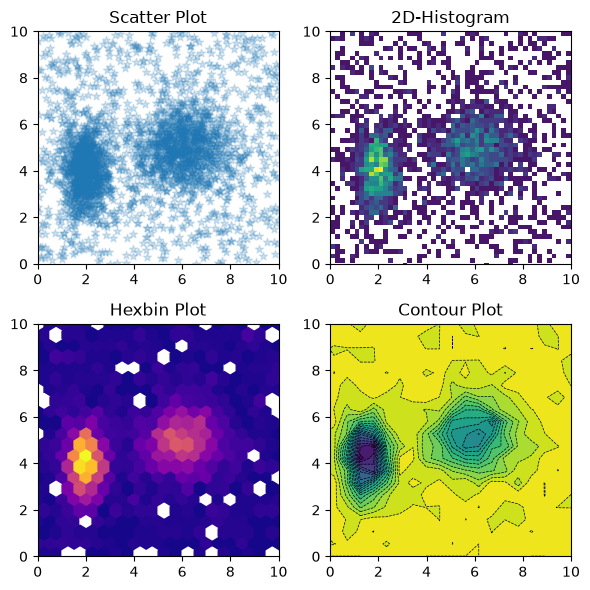

In [20]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))

axs[0, 0].set_title('Scatter Plot')
axs[0, 0].scatter(points["x"], points["y"], alpha=0.2, lw=1, marker="*")

axs[0, 1].set_title('2D-Histogram')
axs[0, 1].hist2d(points["x"], points["y"], bins=50, cmap=vir, vmin=1e-14)

axs[1, 0].set_title('Hexbin Plot')
axs[1, 0].hexbin(points["x"], points["y"], gridsize=20, cmap=plasm, vmin=1e-14)

axs[1, 1].set_title('Contour Plot')
hist, xedges, yedges = np.histogram2d(points["y"], points["x"], density=True, bins=20)
axs[1, 1].contour(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                  levels=20, colors='black', linestyles='--', linewidths=0.5)
axs[1, 1].contourf(hist, extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
                   levels=20, cmap="viridis_r")

for x in range(2):
    for y in range(2):
        axs[x, y].set_xlim([0, 10])
        axs[x, y].set_ylim([0, 10])

fig.tight_layout()
plt.show()

<a id="saving"></a>
## 7. Saving a figure

A figure that only exists inside the notebook is of limited use. `savefig` writes it
to disk, and the file extension decides the format — `.png`, `.pdf`, `.svg`.

In [21]:
fig.savefig("fig_2dhistograms.png")

print("fig_2dhistograms.png written next to this notebook")

fig_2dhistograms.png written next to this notebook


IPython can display an image file from disk, which is a quick way to confirm that
what was saved is what you expected.

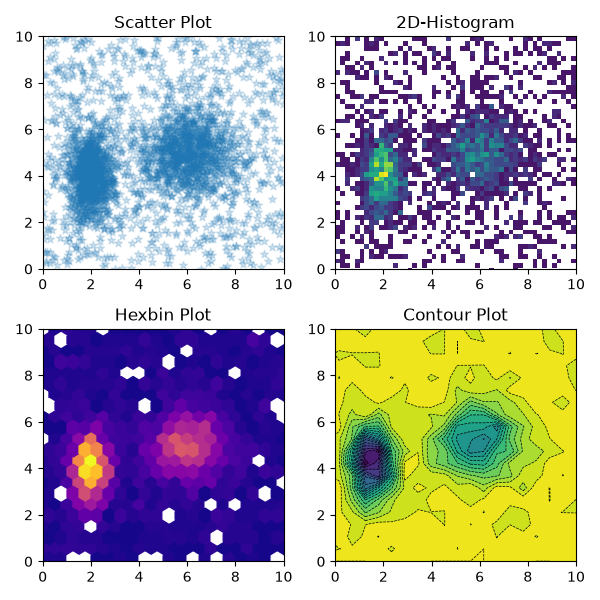

In [22]:
from IPython.display import Image

Image(filename="fig_2dhistograms.png")

Matplotlib can draw far more than what we covered here. The plot-type gallery is
the best place to look for the one you need:
[matplotlib.org/stable/plot_types](https://matplotlib.org/stable/plot_types/index.html)

The next notebook turns to **Plotly**, which brings back the interactivity we had
with hvPlot while keeping much of matplotlib's control.